In [1]:
import os
import json
import time
import argparse
from typing import Tuple, Optional
import re

import numpy as np
from scipy.optimize import minimize

#few and SEF imports
from few.waveform import GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import KerrEccEqFlux
from few.utils.geodesic import get_fundamental_frequencies
from scipy.interpolate import CubicSpline
from scipy.integrate import cumulative_trapezoid
from few.utils.constants import MTSUN_SI

from fastlisaresponse import ResponseWrapper
from lisatools.detector import EqualArmlengthOrbits
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from stableemrifisher.utils import generate_PSD, inner_product
from stableemrifisher.fisher import StableEMRIFisher
import matplotlib.pyplot as plt

from config_paris import Config, ObjectiveTracker
from misc import *
try:
    import cupy as cp
    xp=cp
except:
    xp=np
    print("CuPy not found, using NumPy instead. For GPU acceleration, please install CuPy.")

from inference import  prepare_true_waveform

startup


[INFO] Finished loading modules and building ResponseWrapper
[INFO] Finished generating true waveform
shape check - waveform_true: (3, 3155814) PSD_funcs: (3, 1577907)
[TRUE] SNR: 184.186765
[TRUE] SNR - Channel 0: 28.590175
[TRUE] SNR - Channel 1: 24.933803
[TRUE] SNR - Channel 2: 180.237820
[INFO] Frequency resolution delta_f: 3.168755e-08 Hz, Number of frequency bins: 1577908
freq_max: 0.050000 Hz and Freq_min: 0.000000 Hz


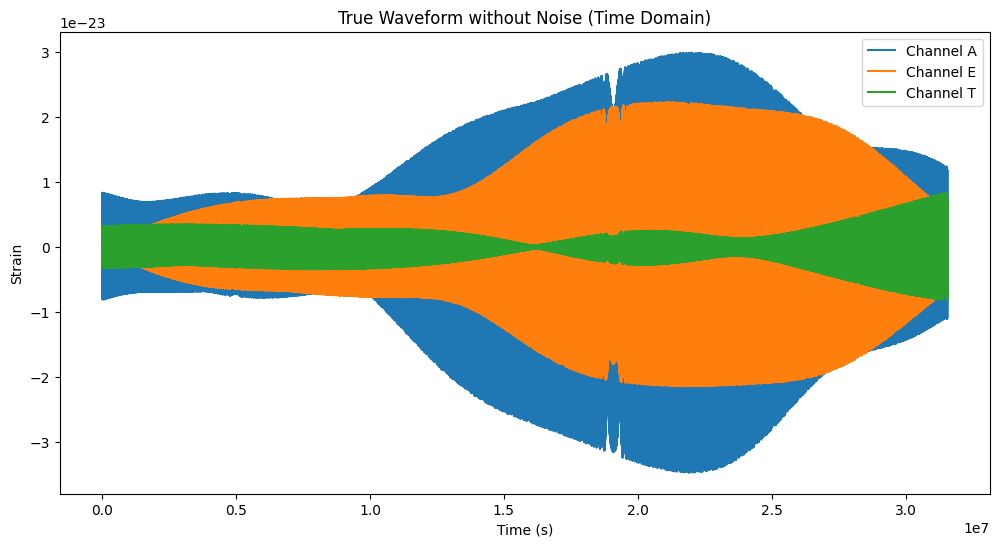

[INFO] Added noise to true waveform FFT

shape of waveform_true_fft after noise addition: (3, 1577907)


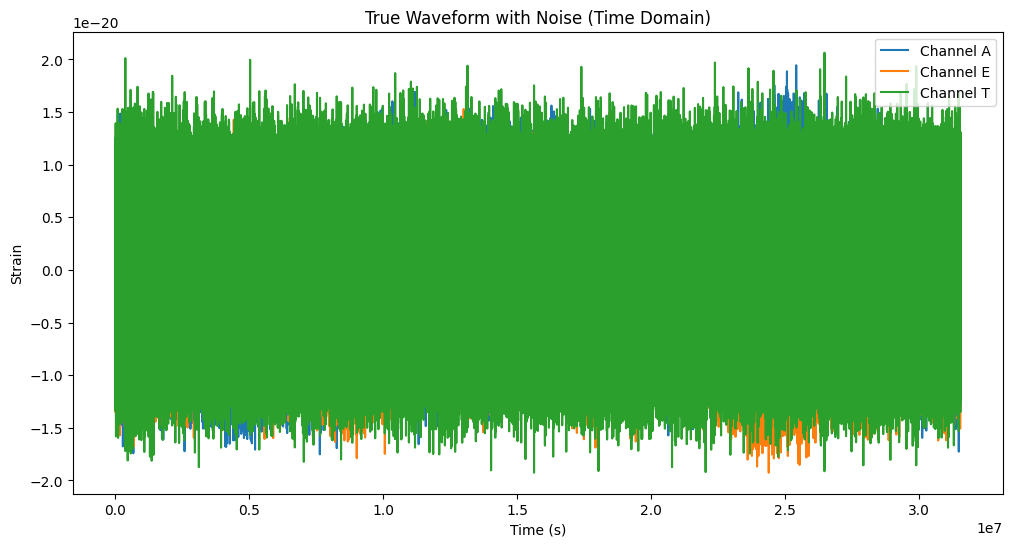

Length of PSD: 1577907


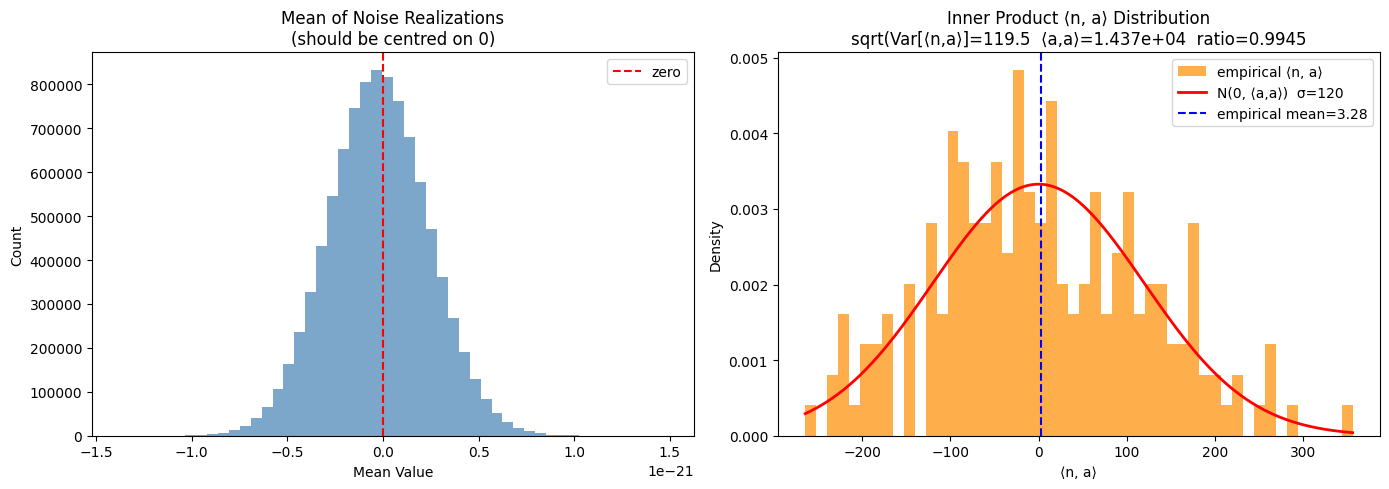

  Noise model consistency check
  Backend                : CuPy (GPU)
  Realizations           : 200
  N time samples         : 3155812  |  PSD bins passed: 1577906
  N (template samples)   : 3155814  →  aligned to 3155812
  Max |mean noise|       : 1.4832e-21  (expect ≈ 0)
  E[⟨n, a⟩]             : 3.2804e+00           (expect ≈ 0)
  Var[⟨n, a⟩]           : 14287.8
  ⟨a, a⟩                : 14367.1
  Ratio Var/⟨a,a⟩       : 0.994484          (expect ≈ 1.0)
Noise consistency check results: {'mean_noise': array([[-3.08572637e-22,  5.21234944e-22, -3.09194809e-22, ...,
        -2.71103137e-22,  2.98321182e-22,  2.02109510e-22],
       [ 5.50421568e-23, -1.07322797e-22,  3.25350610e-22, ...,
        -2.30612469e-22,  2.31649956e-22,  2.19601881e-22],
       [-3.24760315e-22,  9.12728428e-23,  3.47851399e-23, ...,
        -2.56312609e-22, -3.72123314e-22,  5.36292394e-22]],
      shape=(3, 3155812)), 'inner_products': array([ 202.77357066, -194.17222559,  -52.51708988, -173.73790148,
     

{'m1': np.float64(1000000.0),
 'm2': np.float64(10.0),
 'a': np.float64(0.9),
 'p0': np.float64(7.5),
 'e0': np.float64(0.5),
 'Y0': np.float64(1.0),
 'dist': np.float64(5.0),
 'qS': np.float64(0.7853981633974483),
 'phiS': np.float64(1.0),
 'qK': np.float64(1.0),
 'phiK': np.float64(1.0471975511965976),
 'Phi_phi0': np.float64(0.9),
 'Phi_theta0': np.float64(0.5),
 'Phi_r0': np.float64(0.4),
 'dt': 10,
 'T': 1.0,
 'chi2': 0.0,
 'dev_1': 0.0,
 'dev_2': 0.0,
 'waveform_response': <fastlisaresponse.response.ResponseWrapper at 0x1552bcd7cd10>,
 'PSD_funcs': array([[6.81763434e-35, 1.70440862e-35, 7.57514968e-36, ...,
         1.61311193e-40, 1.61310358e-40, 1.61309523e-40],
        [6.81763434e-35, 1.70440862e-35, 7.57514968e-36, ...,
         1.61311193e-40, 1.61310358e-40, 1.61309523e-40],
        [2.65994853e-56, 1.06395802e-55, 2.39388950e-55, ...,
         5.36070468e-40, 5.36068302e-40, 5.36066135e-40]],
       shape=(3, 1577907)),
 'waveform_true_fft': array([[-6.25689796e-15-2.560

In [2]:
seed= 42   
param_names_to_infer = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']  
params_name = ["m1","m2","a","p0","e0","xI0","dist","qS","phiS","qK","phiK",
                         "Phi_phi0","Phi_theta0","Phi_r0"]      

params = np.array([1e6,1e1,0.9, 7.5,  5.00000000e-01,  1.00000000e+00,
          5.0,  np.pi/4,  1.0, 1,  np.pi/3,  9.00000000e-01, 5.00000000e-01,  4.00000000e-01])

signal_param = {"m1": 1e6,
    "m2": 10.0,
    "a": 0.9,
    "p0": 7.5,
    "e0": 0.5,
    "xI0": 1.0,
    "dist": 5.0,
    "qS": np.pi/4,
    "phiS": 1,
    "qK": 1,
    "phiK": np.pi/3,
    "Phi_phi0": 0.9,
    "Phi_theta0": 0.5,
    "Phi_r0": 4.00000000e-01,
}
signal_param_array = np.array(list(signal_param.values()))
dt = 10  #Time step for waveform generation; default 0.1s
T= 1.0

chi2 = 0.0 
dev_1 = 0.0
dev_2 = 0.0

emri_kwargs = {"T": T, "dt": dt,'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': dev_1, 'dev_2': dev_2}
add_kwargs = {'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': dev_1, 'dev_2': dev_2}

# if target_func in ('optimal_snr', 'optimal_snr_phase_max','time_max'):
        
ctx = prepare_true_waveform(signal_param_array, emri_kwargs, add_kwargs,add_noise=True, use_gpu=True,seed=seed)

snr_2 = inner_prod(ctx['waveform_true_fft_without_noise'], ctx['waveform_true_fft_without_noise'], ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
ctx

In [3]:
noise_f =  ctx['noise']
Respsone = ctx['waveform_response']


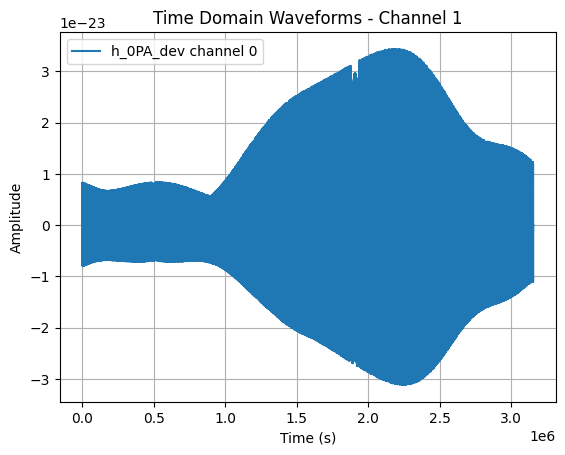

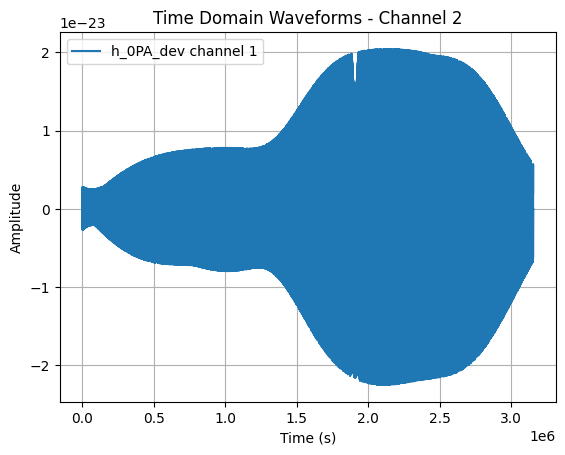

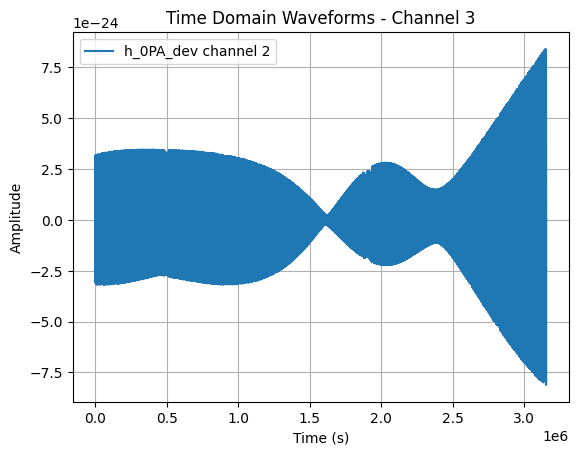

square of overlap in each channel 1: 28.588899448124387
square of overlap in each channel 2: 24.932707811298787
square of overlap in each channel 3: 177.89738646532678
noise inner product with 0PA: -158.98168111145617
detection SNR -0.8849518891174428
Actual overlap: 181.896798217155
detection SNR using true waveform: 184.171610091706
detection SNR using actual signal: 183.28665820258854


In [5]:
x_best_fit_0PA_dev =[1000008.5746504833, 9.999570425057946, 0.9000237990385593, 7.499889256379131, 0.500009070433986, 0.7832270952980772, 1.0127652339855113, 1.0921650231160118, 0.3960954729726116, 2.412658875547302, -2.571125543385933]
add_kwargs = {'chi2': 0,'evolve_1PA': False,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': x_best_fit_0PA_dev[-2], 'dev_2': x_best_fit_0PA_dev[-1]}

m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0,dev_1,dev_2 = x_best_fit_0PA_dev

wave_params = [m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs['chi2'],add_kwargs['evolve_1PA'],add_kwargs['evolve_primary'],
                    add_kwargs['evolve_2PA'], add_kwargs['deviation_included'],add_kwargs['dev_1'],add_kwargs['dev_2']]

emri_kwargs =  {"T": ctx['T'], "dt": ctx['dt'],'chi2': add_kwargs['chi2'],'evolve_1PA': add_kwargs['evolve_1PA'],
                    'evolve_primary': add_kwargs['evolve_primary'],'evolve_2PA': add_kwargs['evolve_2PA'],'deviation_included': add_kwargs['deviation_included'],
               'dev_1': add_kwargs['dev_1'], 'dev_2': add_kwargs['dev_2']}

h_0PA_dev = xp.array(Respsone(*wave_params, **emri_kwargs))
for i in range(3):
    plt.plot(h_0PA_dev[i].get(), label=f"h_0PA_dev channel {i}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title(f"Time Domain Waveforms - Channel {i+1}")
    plt.legend()
    plt.grid()
    plt.show()
h_0PA_dev_f = compute_fft_with_windowing(h_0PA_dev, ctx['dt'], ctx['N_fiducial'],type=None,use_gpu=True,n_channels=3)
n_hf_dev = inner_prod(h_0PA_dev_f, noise_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
for i in range(3):
    print(f"square of overlap in each channel {i+1}:", np.sqrt(inner_prod(h_0PA_dev_f[i], ctx['waveform_true_fft_without_noise'][i], ctx['PSD_funcs'][i], ctx['delta_f'], xp=xp)))
print("noise inner product with 0PA:", n_hf_dev)
optimal_snr_h_0PA_dev = inner_prod(h_0PA_dev_f, h_0PA_dev_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp
                               )
print("detection SNR", n_hf_dev/np.sqrt(optimal_snr_h_0PA_dev))

actual_overlap = inner_prod(ctx['waveform_true_fft_without_noise'], h_0PA_dev_f, ctx['PSD_funcs'], ctx['delta_f'], xp=xp)
print("Actual overlap:", np.sqrt(actual_overlap))
print("detection SNR using true waveform:", actual_overlap/np.sqrt(optimal_snr_h_0PA_dev))
print("detection SNR using actual signal:", actual_overlap/np.sqrt(optimal_snr_h_0PA_dev)  + n_hf_dev/np.sqrt(optimal_snr_h_0PA_dev))

/tmp/ipykernel_740290/2549886902.py:148: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


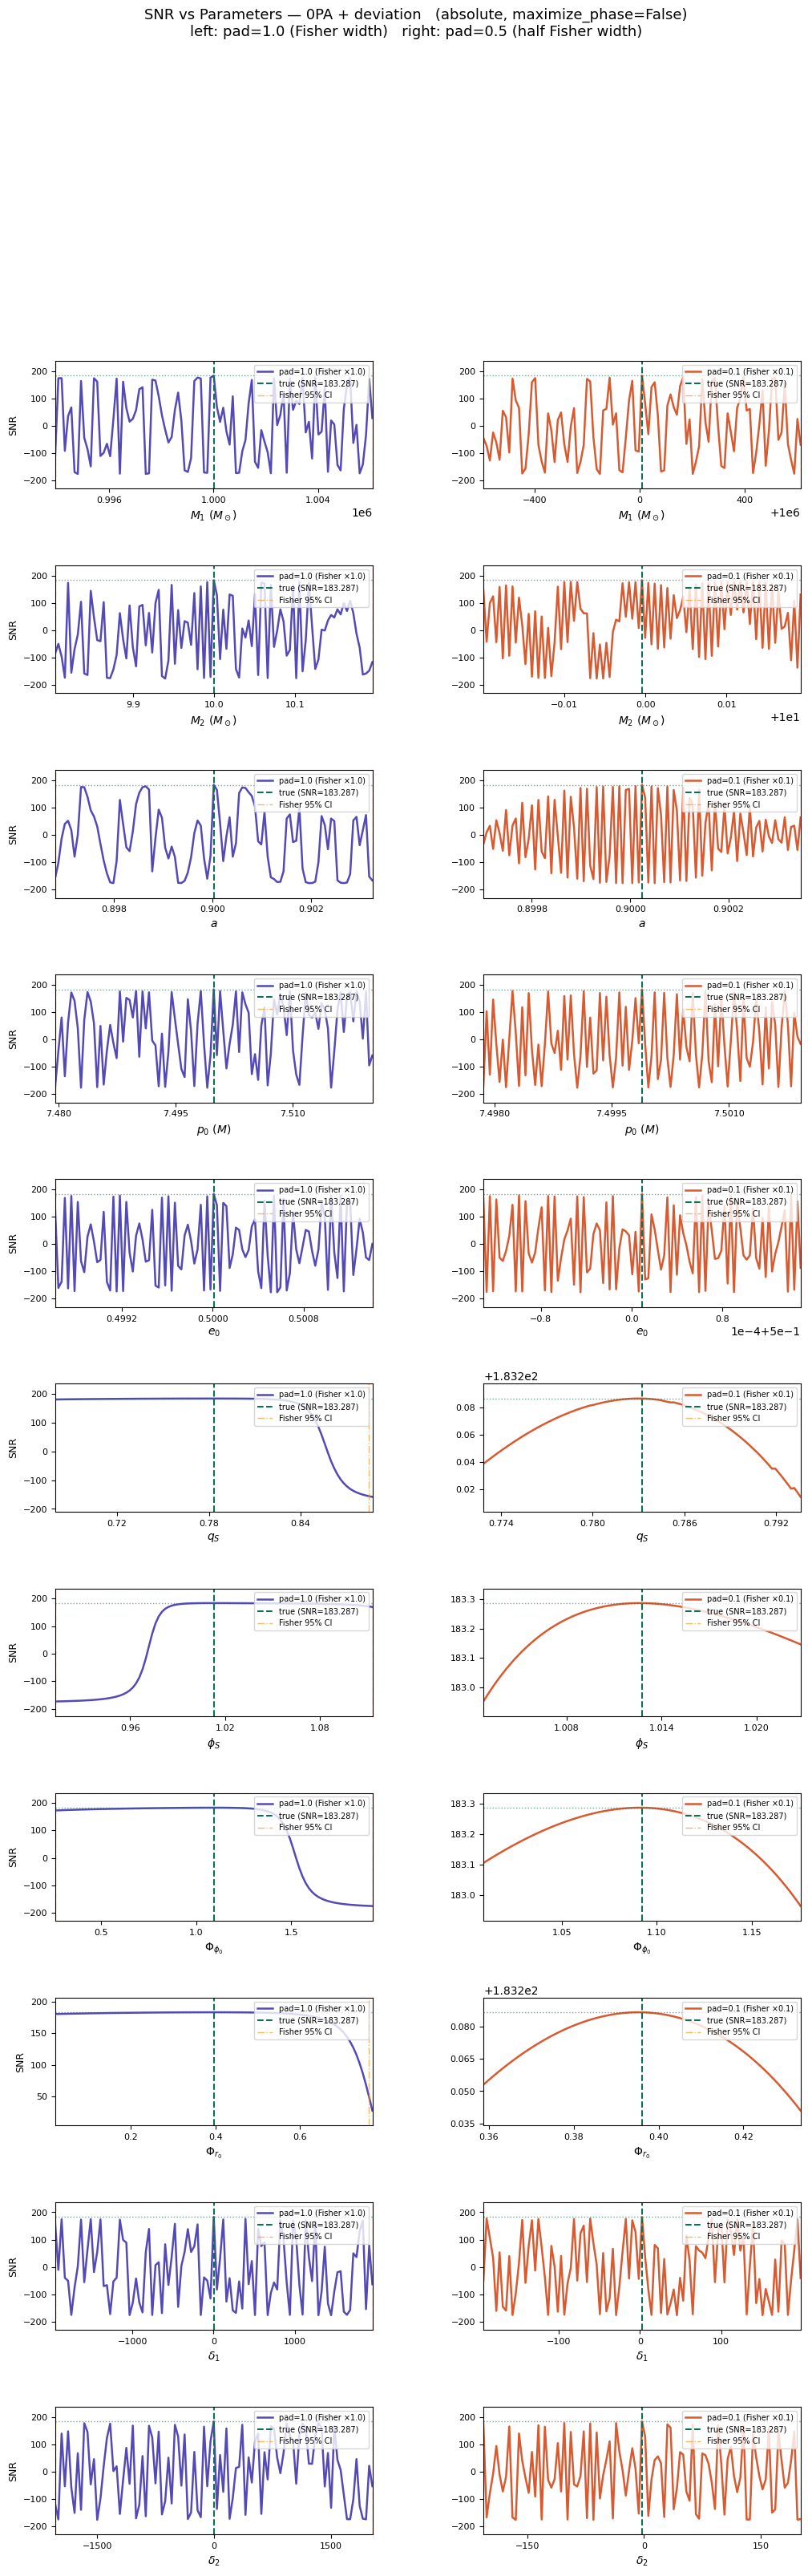

In [6]:
from matplotlib.gridspec import GridSpec

# ── Parameter setup ────────────────────────────────────────────────────────────
param_names_label = [r'$M_1\ (M_\odot)$', r'$M_2\ (M_\odot)$', r'$a$',
    r'$p_0\ (M)$', r'$e_0$', r'$q_S$', r'$\phi_S$', r'$\Phi_{\phi_0}$', r'$\Phi_{r_0}$',
    r'$\delta_1$', r'$\delta_2$']

x_best_fit_0PA_dev = [1000008.5746504833, 9.999570425057946, 0.9000237990385593, 7.499889256379131, 0.500009070433986, 0.7832270952980772, 1.0127652339855113, 1.0921650231160118, 0.3960954729726116, 2.412658875547302, -2.571125543385933]

bounds_0PA_dev = [(np.float64(993950.8224553468), np.float64(1006066.8240397365)), (np.float64(9.80398955157798), np.float64(10.195153552639114)), (np.float64(0.8968026714190693), np.float64(0.9032450928273024)), (np.float64(7.4796071615029245), np.float64(7.520169603874141)), (np.float64(0.4986103429307512), np.float64(0.5014076460743048)), (np.float64(0.6769171457320717), np.float64(0.8846159195223444)), (np.float64(0.9125479817512355), np.float64(1.1130017285805855)), (np.float64(0.25698836077009135), np.float64(1.9274206657195307)), (np.float64(0.013837221586475101), np.float64(0.7622800208640665)), (np.float64(-1954.2169601673777), np.float64(1959.03234093206)), (np.float64(-2038.4967231028004), np.float64(2033.354888912194))]

PARAM_BOUNDS = [
    (None, None),
    (None, None),
    (-0.9999, 0.9999),
    (1.0, None),
    (0.0, 0.9999),
    (0.0, np.pi),
    (0.0, 2*np.pi),
    (0.0, 2*np.pi),
    (0.0, 2*np.pi),
    (None, None),
    (None, None),
]

fixed = {
    'waveform_response': ctx['waveform_response'],
    'PSD':               ctx['PSD_funcs'],
    'dt':                ctx['dt'],
    'T':                 ctx['T'],
    'N_fiducial':        ctx['N_fiducial'],
    'waveform_true_fft': ctx['waveform_true_fft'],
    'xp':                np,
    'delta_f':           ctx['delta_f'],
    'use_gpu':           True,
}

N_PARAMS    = len(x_best_fit_0PA_dev)
N_POINTS    = 100
# pad=1.0 → window = full Fisher width centred on true point
# pad=0.5 → window = half Fisher width (zoomed in)
PAD_FACTORS = [1.0, 0.1]


# ── Grid builder — true point always an exact node ─────────────────────────────
def make_grid(idx, pad, n_points=N_POINTS):
    lo, hi   = bounds_0PA_dev[idx]
    half     = (hi - lo) / 2.0
    true_val = x_best_fit_0PA_dev[idx]

    raw_lo = true_val - pad * half
    raw_hi = true_val + pad * half

    phys_lo, phys_hi = PARAM_BOUNDS[idx]
    if phys_lo is not None:
        raw_lo = max(raw_lo, phys_lo)
    if phys_hi is not None:
        raw_hi = min(raw_hi, phys_hi)

    frac_left = (true_val - raw_lo) / (raw_hi - raw_lo)
    n_left    = max(2, round(n_points * frac_left))
    n_right   = max(2, n_points - n_left + 1)

    left  = np.linspace(raw_lo,   true_val, n_left)
    right = np.linspace(true_val, raw_hi,   n_right)

    return np.concatenate([left, right[1:]])


# ── SNR profile ────────────────────────────────────────────────────────────────
def compute_snr_profile(idx, pad, n_points=N_POINTS):
    grid = make_grid(idx, pad, n_points)
    snr  = np.empty(len(grid))

    theta = list(x_best_fit_0PA_dev)
    for k, x in enumerate(grid):
        theta[idx] = x
        m1, m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0, dev_1, dev_2 = theta
        # dev_1/dev_2 updated per iteration so varying them sweeps correctly
        add_kwargs = {'chi2': 0.0, 'evolve_1PA': False, 'evolve_primary': False,
                      'evolve_2PA': False, 'deviation_included': True,
                      'dev_1': dev_1, 'dev_2': dev_2}
        snr[k] = calculate_detection_snr_0pa_vs_1pa(
            m1, m2, a, p0, e0, ctx['Y0'], ctx['dist'], qS, phiS, ctx['qK'], ctx['phiK'],
            Phi_phi0, ctx['Phi_theta0'], Phi_r0, add_kwargs,
            maximize_phase=False,
            **fixed)

    true_idx = np.argmin(np.abs(grid - x_best_fit_0PA_dev[idx]))
    snr_true = snr[true_idx]

    return grid, snr, snr_true


# ── Plotting ───────────────────────────────────────────────────────────────────
PAD_COLORS = ['#534AB7', '#D85A30']
PAD_LABELS = [f'pad={p} (Fisher ×{p})' for p in PAD_FACTORS]

def plot_snr_profiles():
    ncols = len(PAD_FACTORS)   # 2 columns: wide | zoomed
    nrows = N_PARAMS            # 11 rows, one per parameter

    fig = plt.figure(figsize=(6 * ncols, 3.2 * nrows))
    gs  = GridSpec(nrows, ncols, figure=fig, hspace=0.6, wspace=0.35)

    for idx in range(N_PARAMS):
        for col, (pad, color, label) in enumerate(zip(PAD_FACTORS, PAD_COLORS, PAD_LABELS)):
            ax = fig.add_subplot(gs[idx, col])

            grid, snr, snr_true = compute_snr_profile(idx, pad)

            ax.plot(grid, snr, color=color, lw=1.8, label=label)

            # horizontal reference at true-point SNR
            ax.axhline(snr_true, color='#0F6E56', lw=1.0, ls=':', alpha=0.6)

            # vertical true-point marker
            ax.axvline(x_best_fit_0PA_dev[idx], color='#0F6E56',
                       lw=1.5, ls='--', label=f'true (SNR={snr_true:.3f})')

            # Fisher bounds as lines (visible at any zoom level)
            lo, hi = bounds_0PA_dev[idx]
            ax.axvline(lo, color='#EF9F27', lw=1.0, ls='-.', alpha=0.7)
            ax.axvline(hi, color='#EF9F27', lw=1.0, ls='-.', alpha=0.7,
                       label='Fisher 95% CI')

            # x-axis limits follow the grid exactly — different per pad and per panel
            ax.set_xlim(grid[0], grid[-1])

            # y-axis tight around SNR range in this window
            snr_min, snr_max = np.min(snr), np.max(snr)
            margin = (snr_max - snr_min) * 0.15 if snr_max > snr_min else abs(snr_true) * 0.01
            ax.set_ylim(snr_min - margin, snr_max + margin)

            if col == 0:
                ax.set_ylabel(r'SNR', fontsize=9)

            ax.set_xlabel(param_names_label[idx], fontsize=10)
            ax.tick_params(labelsize=8)
            ax.xaxis.set_major_locator(plt.MaxNLocator(4))
            ax.yaxis.set_major_locator(plt.MaxNLocator(5))
            ax.ticklabel_format(style='sci', axis='both', scilimits=(-3, 4), useOffset=True)
            ax.legend(fontsize=7, loc='upper right')

    fig.suptitle('SNR vs Parameters — 0PA + deviation   (absolute, maximize_phase=False)\n'
                 'left: pad=1.0 (Fisher width)   right: pad=0.5 (half Fisher width)',
                 fontsize=13, y=1.005)
    plt.tight_layout()
    plt.show()


if __name__ == '__main__':
    plot_snr_profiles()